In [23]:

import matplotlib.pyplot as plt
import math
import numpy as np


u_L = [0.5] * 360
u_R = [0.7] * 360

# Радиусы колес 
W_R = 1
W_L = 1

# Колесная база робота
B = 2

T = 0.1

def s_L(k):
    return W_L * u_L[k]

def s_R(k):
    return W_R * u_R[k] 

def s_t(k):
    return (s_R(k) + s_L(k)) / 2

def s_r(k):
    return (s_R(k) - s_L(k)) / 2 * B

length_u_L = len(u_L)

x_true = [0.0]
y_true = [0.0]
r_true = [0.0]


for k in range(length_u_L):
    x_true.append(x_true[k] + T * s_t(k) * math.cos(r_true[k]) - (math.pow(T, 2) / 2 * s_t(k) * s_r(k) * math.sin(r_true[k])))
    y_true.append(y_true[k] + T * s_t(k) * math.sin(r_true[k]) + (math.pow(T, 2) / 2 * s_t(k) * s_r(k) * math.cos(r_true[k])))
    r_true.append(r_true[k] + T * s_r(k))


x_obsession = np.array(x_true) + np.random.normal(0, 0.05, length_u_L + 1)
y_obsession = np.array(y_true) + np.random.normal(0, 0.05, length_u_L + 1)
r_obsession = np.array(r_true) + np.random.normal(0, 0.05, length_u_L + 1)

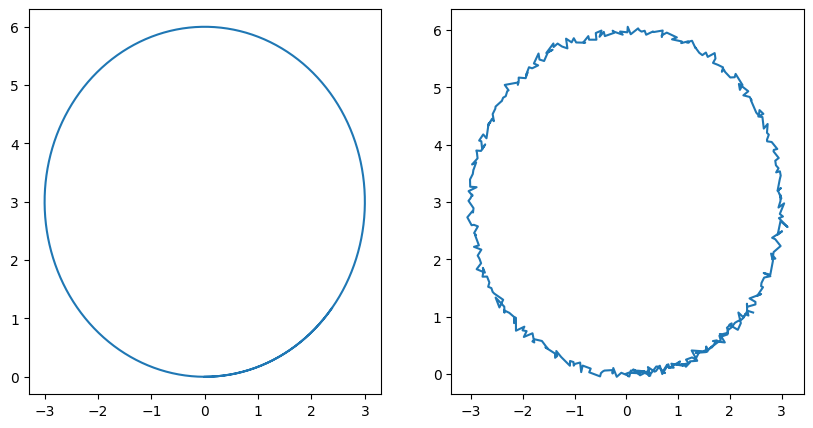

In [37]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(x_true,y_true)
plt.subplot(1, 2, 2)
plt.plot(x_obsession,y_obsession)
plt.show()

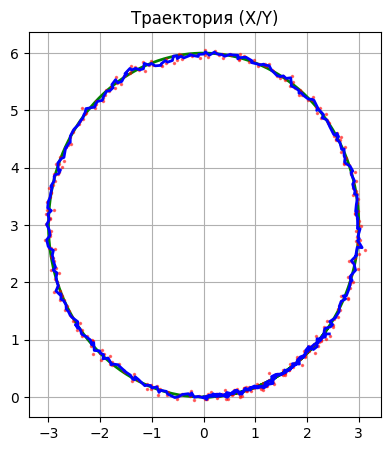

In [35]:

X_est = np.array([[0.0],
                [0.0],
                [0.0]])
X_history = [np.copy(X_est)]

# Ковариация ошибки (P), Шум процесса (Q), Шум измерения (R)
P = np.eye(3) *  0.5
Q = np.eye(3) * 0.01
R = np.eye(3) * 0.1**2

def get_Jacobian(k, state):
    """Вычисление матрицы Якобиана F"""
    # Исправлена ошибка в знаке для df2dr (там должно быть +)
    df1dr = -T * s_t(k) * math.sin(state[2, 0]) - (T**2 / 2) * s_t(k) * s_r(k) * math.cos(state[2, 0])
    df2dr =  T * s_t(k) * math.cos(state[2, 0]) - (T**2 / 2) * s_t(k) * s_r(k) * math.sin(state[2, 0])
    
    return np.array([
        [1, 0, df1dr],
        [0, 1, df2dr],
        [0, 0, 1]
    ])

def predict(state, k):
    """Функция прогноза f"""
    x, y, r = state[0, 0], state[1, 0], state[2, 0]
    x_p = x + T * s_t(k) * math.cos(r) - (T**2 / 2) * s_t(k) * s_r(k) * math.sin(r)
    y_p = y + T * s_t(k) * math.sin(r) + (T**2 / 2) * s_t(k) * s_r(k) * math.cos(r)
    r_p = r + T * s_r(k)
    return np.array([[x_p], [y_p], [r_p]])

# Запуск фильтра
for k in range(length_u_L):
    # 1. Прогноз (Prediction)
    X_pred = predict(X_est, k)
    F = get_Jacobian(k, X_est)
    P_pred = F @ P @ F.T + Q  # Используем @ для умножения матриц

    # 2. Измерение (Measurement)
    Z_k = np.array([[x_obsession[k+1]], [y_obsession[k+1]], [r_obsession[k+1]]])
    H = np.eye(3) # Матрица наблюдения (измеряем всё напрямую)

    # 3. Коррекция (Update)
    S = H @ P_pred @ H.T + R
    K = P_pred @ H.T @ np.linalg.inv(S) # Исправлена формула Gain (добавлена inv)
    
    # Обновление состояния с учетом невязки (Z - H*X_pred)
    X_est = X_pred + K @ (Z_k - H @ X_pred)
    P = (np.eye(3) - K @ H) @ P_pred
    
    X_history.append(X_est.copy())

X_history = np.array(X_history).reshape(-1, 3)

plt.figure(figsize=(10, 5))

# График траектории (X vs Y)
plt.subplot(1, 2, 1)
plt.plot(x_true, y_true, 'g-', label='Истинная', linewidth=2)
plt.plot(x_obsession, y_obsession, 'r.', label='Измерения (Шум)', markersize=3, alpha=0.5)
plt.plot(X_history[:, 0], X_history[:, 1], 'b-', label='EKF Оценка', linewidth=2)
plt.title('Траектория (X/Y)')
plt.grid(True)